<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project2/pafolabi_DIAML_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data, Inference, and Applied Machine Learning**: Project Assignment II

In [25]:
#Imports all neccessary Python libraries
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

##Question 1
**Data source**: [World Bank Indicators](https://data.worldbank.org/indicator)

###a. Before looking at the data, state what kind of relationship you expect.
Before looking at the data of **GDP per capita (current
US$)** and **Prevalence of underweight, weight for age
(% of children under 5)**, I expect to see the following relationship:
1. As the world GDP increases (the GDP of countries), I expect that the percentage of underweight children decreases, yielding an inverse relationship between world GDP and percentage of underweight children.
2. The cumulative world GDP over several years.
3. The amount, either in percentage or in realised value, various countries contributed to the world GDP growth in an accounting year.
4. The percentage of underweight children in the world over a good number of years.
---
###b. Clean the data and say what you removed and why. Report how many years of observations and how many distinct countries you are left with.

In [2]:
# Data ingestion and cleaning

# 1. World GDP Data Ingestion
world_gdp_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv',
                           skiprows=4)
world_gdp_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')
world_gdp_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Indicator_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv')


# 2. World Percentage of Underage Children Data Ingestion
world_pcnt_underwgth_chld_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv',
    skiprows=4)
world_pcnt_underwgth_chld_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Country_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')
world_pcnt_underwgth_chld_metadata_indicator_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_percent_underweight/Metadata_Indicator_API_SH.STA.MALN.ZS_DS2_en_csv_v2_334227.csv')

# 3. Exploration of DFs
#world_gdp_df.head()
#world_gdp_metadata_country_df.head()
#world_gdp_indicator_df.head()

#world_pcnt_underwgth_chld_df.count()
#world_pcnt_underwgth_chld_metadata_country_df.tail()
#world_pcnt_underwgth_chld_metadata_indicator_df.head()

# 4. Data cleaning operations
region_notna = world_gdp_metadata_country_df['Region'].notna()
country_codes = world_gdp_metadata_country_df[region_notna]['Country Code']
clean_world_gdp_df = world_gdp_df[world_gdp_df['Country Code'].isin(country_codes)]
clean_world_underweight_df = world_pcnt_underwgth_chld_df[world_pcnt_underwgth_chld_df['Country Code'].isin(country_codes)]

world_gdp_long_df = clean_world_gdp_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_gdp_df.columns],
    var_name='Year',
    value_name='GDP_per_capita'
)

world_pcnt_underwight_long_df = clean_world_underweight_df.melt(
    id_vars=['Country Name', 'Country Code'],
    value_vars=[str(year) for year in range(1960, 2026) if str(year) in clean_world_underweight_df.columns],
    var_name='Year',
    value_name='Percentage_Underweight'
)

merged_df = pd.merge(
    world_gdp_long_df,
    world_pcnt_underwight_long_df,
    on=['Country Code', 'Country Name','Year'],
    how='inner'
)

final_df = merged_df.dropna(subset=['GDP_per_capita', 'Percentage_Underweight'])
final_df['Year'] = final_df['Year'].astype(int)


C:\Users\afola\AppData\Local\Temp\ipykernel_11508\787208523.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['Year'] = final_df['Year'].astype(int)


### Explanation of Data Cleaning

1.  **Filtering by Region**: Initially, both the World GDP and Underweight Children datasets contained aggregate entities (e.g., 'World', 'European Union') which are not individual countries. These were removed by filtering for 'Country Code' values that corresponded to entries with a non-null 'Region' in the `world_gdp_metadata_country_df`. This ensures that only actual country data is considered.
2.  **Melting DataFrames**: The raw data was in a wide format, with each year as a separate column. I transformed both datasets into a 'long' format using `melt()`. This reshaped the data so that each row represents a unique combination of country and year, with separate columns for 'Year', 'Country Name', 'Country Code', and the respective indicator values ('GDP_per_capita' or 'Percentage_Underweight'). This is essential for easier merging and time-series analysis.
3.  **Merging DataFrames**: The GDP per capita and Percentage Underweight data were merged into a single DataFrame (`merged_df`) using 'Country Code', 'Country Name', and 'Year' as common keys. An 'inner' merge was used, meaning only rows that have matching values in all key columns in both DataFrames were kept. This ensures we only have data points where both indicators are available for a given country and year.
4.  **Handling Missing Values**: Finally, rows where either 'GDP_per_capita' or 'Percentage_Underweight' had missing values (NaN) were dropped using `dropna()`. This step ensures that our analysis only uses complete data points, preventing skewing from incomplete observations.
5.  **Data Type Conversion**: The 'Year' column was converted to an integer type for consistency and easier numerical operations.


In [3]:
num_years = final_df['Year'].nunique()
num_countries = final_df['Country Name'].nunique()

print(f"Number of years of observations: {num_years}")
print(f"Number of distinct countries: {num_countries}")

Number of years of observations: 42
Number of distinct countries: 161


### c. Make a scatter plot of malnutrition prevalence against GDP per capita, using all available years and countries. What kind of relationship do you see, and how does it compare with your hypothesis? Then redraw the same plot with GDP per capita on a logarithmic axis, and say which of the two you would publish.

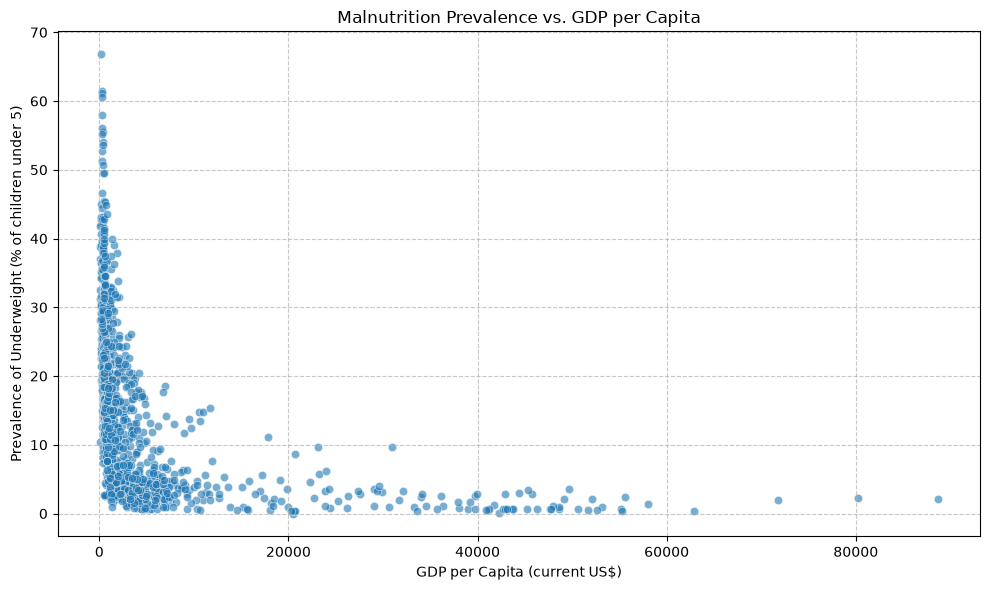

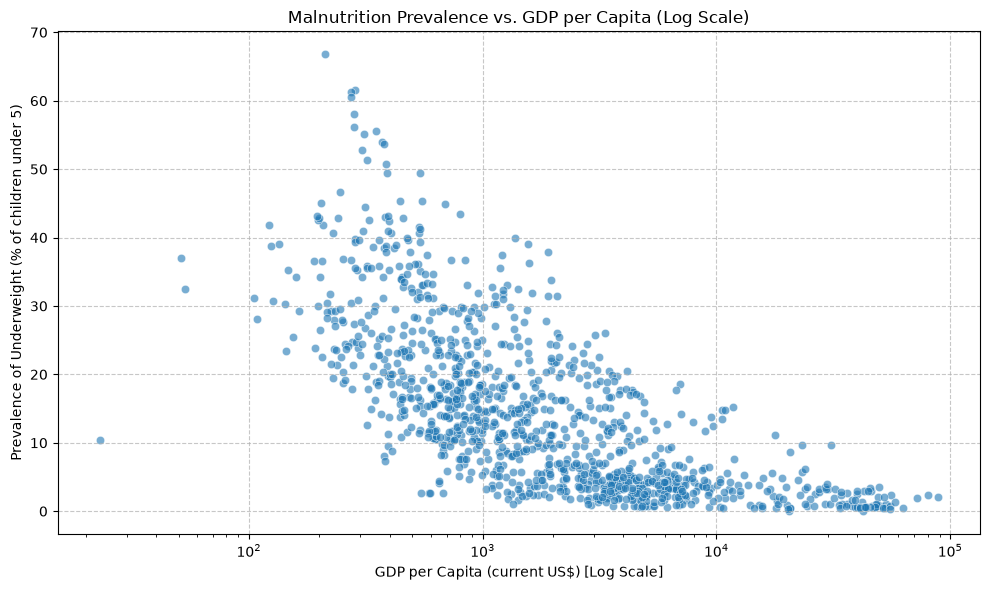

In [4]:
# Scatter plot of malnutrition prevalence against GDP per capita
fig1 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.title('Malnutrition Prevalence vs. GDP per Capita')
plt.xlabel('GDP per Capita (current US$)')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Scatter plot with GDP per capita on a logarithmic axis
fig2 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=final_df, x='GDP_per_capita', y='Percentage_Underweight', alpha=0.6)
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale)')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.c)

**Relationship Observed (Linear Scale)**:

In the first scatter plot (linear scale), we can observe a general trend where as GDP per capita increases, the prevalence of underweight children tends to decrease. This aligns with the initial hypothesis of an inverse relationship. However, the data points are heavily clustered towards the lower end of the GDP per capita scale, making it difficult to discern patterns among countries with lower GDP and to fully appreciate the relationship across the entire range.

**Relationship Observed (Logarithmic Scale)**:

The second scatter plot, with GDP per capita on a logarithmic axis, provides a much clearer view of the relationship. The logarithmic scale compresses the higher GDP values and expands the lower GDP values, spreading out the clustered points and revealing more detail. In this plot, the inverse relationship is more evident and appears more consistent across different income levels. The distribution of data points is more uniform, allowing for better identification of trends and outliers.

**Which plot to publish?**:

I would publish the **scatter plot with GDP per capita on a logarithmic axis**. This is because:

*   **Better Visualization of Skewed Data**: Economic data like GDP per capita often has a heavily skewed distribution, with a few high-income countries and many low-to-middle-income countries. A logarithmic scale effectively handles this skewness, making the distribution of data points more interpretable.
*   **Clearer Trend Identification**: The inverse relationship between GDP per capita and malnutrition prevalence is much more clearly and evenly depicted across the range of GDP values on a logarithmic scale. It allows us to observe nuances in the relationship that are obscured on a linear scale.
*   **Enhanced Detail for Lower GDP Countries**: The logarithmic scale provides more visual emphasis on the differences among lower GDP countries, which are often the most relevant for studying malnutrition.


### d. Make a scatter plot coloured by geographical region and another coloured by income level. Which of the two plots is more informative?

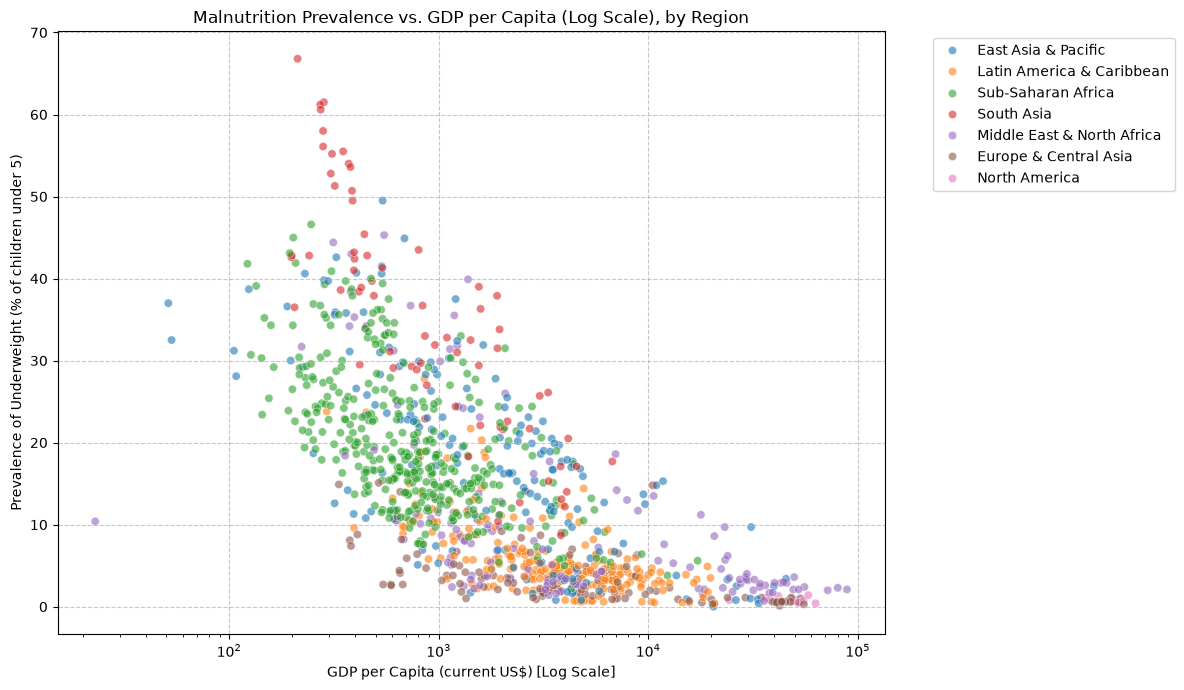

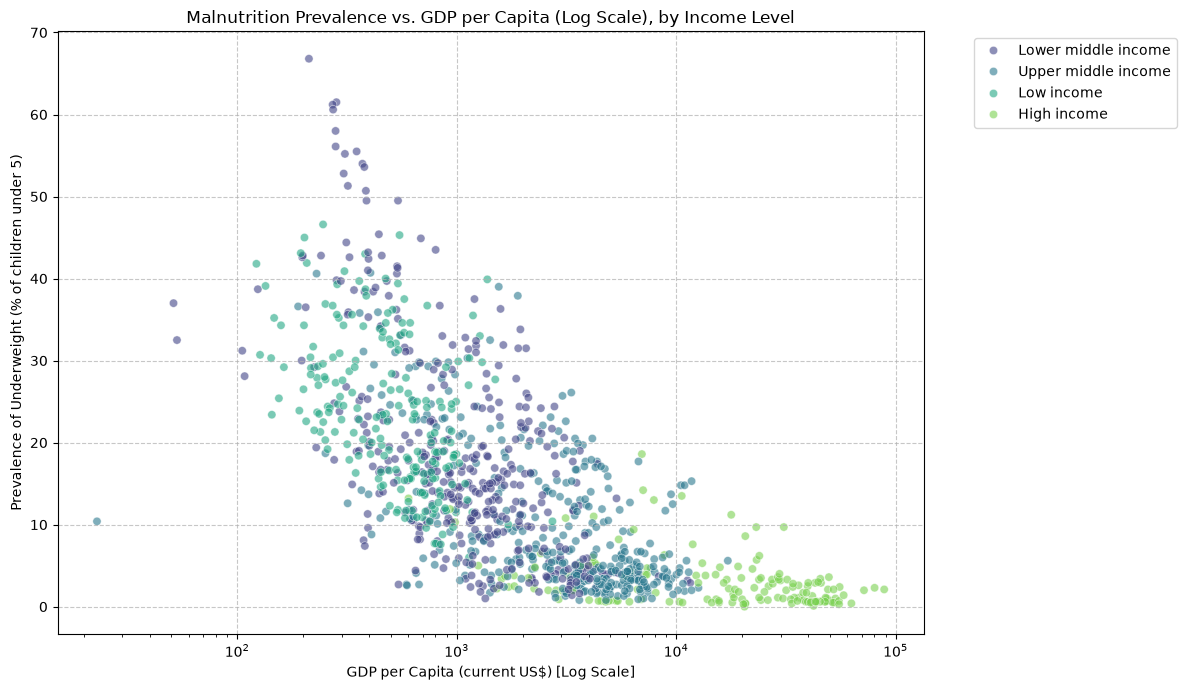

In [5]:
metadata_df = world_gdp_metadata_country_df[['Country Code', 'Region', 'IncomeGroup']].copy()
final_df_with_metadata = pd.merge(final_df, metadata_df, on='Country Code', how='left')

# Scatter plot colored by Geographical Region
fig3 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='Region', alpha=0.6, palette='tab10')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Region')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Scatter plot colored by Income Level
fig4 = plt.figure(figsize=(12, 7))
sns.scatterplot(data=final_df_with_metadata, x='GDP_per_capita', y='Percentage_Underweight', hue='IncomeGroup', alpha=0.6, palette='viridis')
plt.xscale('log')
plt.title('Malnutrition Prevalence vs. GDP per Capita (Log Scale), by Income Level')
plt.xlabel('GDP per Capita (current US$) [Log Scale]')
plt.ylabel('Prevalence of Underweight (% of children under 5)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis of Plots (Question 1.d)

**Which plot is more informative?**

Both plots offer valuable insights, but the **scatter plot colored by Income Level is generally more informative** for understanding the relationship between GDP per capita and malnutrition prevalence.

Here's why:

*   **Direct Correlation with GDP**: Income Group is directly defined by GDP per capita. Therefore, coloring by income level inherently reinforces and clarifies the underlying trend. We can clearly see how countries transition from 'Low income' (typically higher malnutrition, lower GDP) through 'Lower middle income', 'Upper middle income', to 'High income' (typically lower malnutrition, higher GDP), creating a more structured and coherent visual progression.

*   **Clearer Segregation of Trends**: The income level categories tend to group countries with similar economic development and, consequently, similar levels of malnutrition and GDP. This provides a more distinct and understandable segmentation of the data, allowing us to easily identify clusters and patterns within each income group.

*   **Actionable Insights**: From a policy perspective, understanding the relationship within specific income groups can be more actionable. Interventions for malnutrition might differ significantly between a 'Low income' country and a 'High income' country, even if both are in the same geographical region.

**Comparison with Geographical Region Plot**:

The plot colored by geographical region is also useful, as it shows regional disparities. For example, countries in 'Sub-Saharan Africa' might consistently appear at the lower end of the GDP scale with higher malnutrition. However, geographical regions are more diverse in terms of economic development. A single region might contain countries with vastly different GDPs and malnutrition rates, leading to more overlapping and less clear-cut distinctions between the colored groups compared to income levels. While it highlights regional clusters, it doesn't explain the *why* of the GDP-malnutrition relationship as effectively as income groups do.

In conclusion, while both plots offer different perspectives, the **Income Level plot provides a more direct and interpretable visual explanation of the relationship between a country's economic standing (proxied by GDP) and its child malnutrition rates.**

### e. Plot the number of observations per year. What do you observe about reporting frequency?

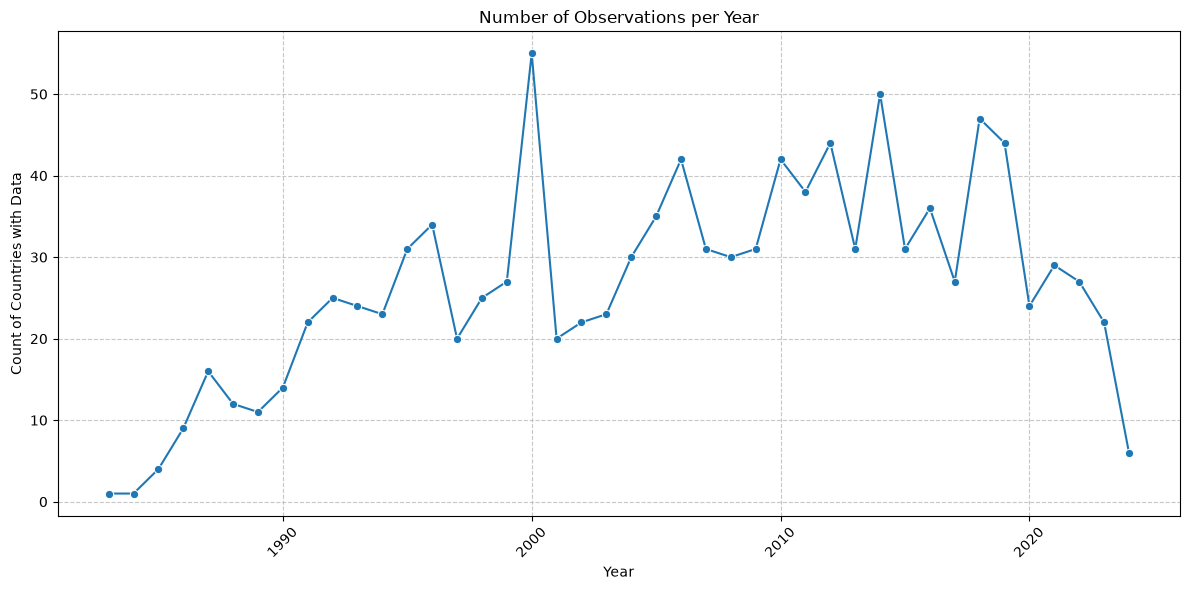

In [6]:
# Plot the number of observations per year
observations_per_year = final_df.groupby('Year').size().reset_index(name='Number of Observations')

fig5 = plt.figure(figsize=(12, 6))
sns.lineplot(data=observations_per_year, x='Year', y='Number of Observations', marker='o')
plt.title('Number of Observations per Year')
plt.xlabel('Year')
plt.ylabel('Count of Countries with Data')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analysis of Reporting Frequency (Question 1.e)

**Observations about reporting frequency:**

The plot showing the 'Number of Observations per Year' reveals several insights into the reporting frequency of both GDP per capita and the prevalence of underweight children:

*   **Sparse Data in Earlier Years**: There are very few observations in the earlier years (e.g., prior to 1980s). This suggests that data collection for one or both indicators was either not comprehensive or not systematically recorded for many countries during those periods.

*   **Increasing Trend over Time**: From the late 1980s or early 1990s, there is a clear upward trend in the number of observations per year. This indicates an improvement in data collection and reporting over time, with more countries providing data for both indicators.

*   **Fluctuations and Gaps**: Despite the general increasing trend, there are noticeable fluctuations and gaps in reporting. Some years have fewer observations than preceding or succeeding years, suggesting that data might not be collected annually for all countries or that reporting can be irregular.

*   **Peak Reporting**: The number of observations appears to peak around the mid-2000s to early 2010s, after which there might be a slight decline or stabilization. This could indicate periods of focused data collection efforts or changes in reporting methodologies.

*   **Most Recent Years Lack Data**: There's a sharp drop-off in observations for the most recent years (e.g., after 2015-2020). This is expected as data collection and compilation often take time, and the latest figures might not yet be available in the datasets. The datasets might also contain 'future' years with no actual data yet, contributing to the drop-off.

In summary, the reporting frequency for these indicators has improved significantly over the decades, though it remains somewhat inconsistent annually, and there is a natural lag in the availability of the most recent data.

## Question 2

For Question 2, we need to download daily closing prices for Wheat (ZW=F), Crude Oil (CL=F), and Gold (GC=F) from Yahoo Finance. This requires the `yfinance` library.

### a. Load the three series and synchronize their timestamps onto a common date index using forward fill.

In [7]:
# Define the tickers and date range
tickers = ['ZW=F', 'CL=F', 'GC=F']
start_date = '2000-08-01'
end_date = '2026-08-31'

# Download data for each ticker
data = {} # Initialize an empty dictionary
for ticker in tickers:
    try:
        ticker_data = yf.download(ticker, start=start_date, end=end_date)
        # Extract the 'Close' price series
        close_series = ticker_data['Close']
        # Explicitly set the name of the series to the ticker symbol
        close_series.name = ticker
        data[ticker] = close_series
    except Exception as e:
        print(f"Could not download data for {ticker}: {e}")

# Create a common date index
# Start with the index of the first series, then add other dates
all_dates = pd.DatetimeIndex([])
for ticker in data:
    all_dates = all_dates.union(data[ticker].index)

# Create a combined DataFrame and synchronize timestamps with forward fill
combined_df_ffill = pd.DataFrame(index=all_dates)
for ticker in data:
    # Now, data[ticker] is already a Series with its name set correctly
    combined_df_ffill = combined_df_ffill.join(data[ticker], how='outer')

# Apply forward fill
combined_df_ffill = combined_df_ffill.ffill()

print("Units for each commodity:")
print("Wheat (ZW=F): USD per bushel")
print("Crude Oil (CL=F): USD per barrel")
print("Gold (GC=F): USD per troy ounce")

print("\nSynchronized DataFrame (first 5 rows with forward fill):")
display(combined_df_ffill.head())

print("\nSynchronized DataFrame (last 5 rows with forward fill):")
display(combined_df_ffill.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Units for each commodity:
Wheat (ZW=F): USD per bushel
Crude Oil (CL=F): USD per barrel
Gold (GC=F): USD per troy ounce

Synchronized DataFrame (first 5 rows with forward fill):


,ZW=F,CL=F,GC=F
2000-08-01,245.00,NaN,NaN
2000-08-02,246.50,NaN,NaN
2000-08-03,242.25,NaN,NaN
2000-08-04,236.50,NaN,NaN
2000-08-07,233.50,NaN,NaN



Synchronized DataFrame (last 5 rows with forward fill):


,ZW=F,CL=F,GC=F
2026-08-24,681.75,85.010002,4640.799805
2026-08-25,685.50,82.360001,4638.100098
2026-08-26,730.50,82.230003,4598.200195
2026-08-27,742.75,83.529999,4609.700195
2026-08-28,767.00,83.400002,4478.100098


### b. Make commodities comparable and plot them on the same graph

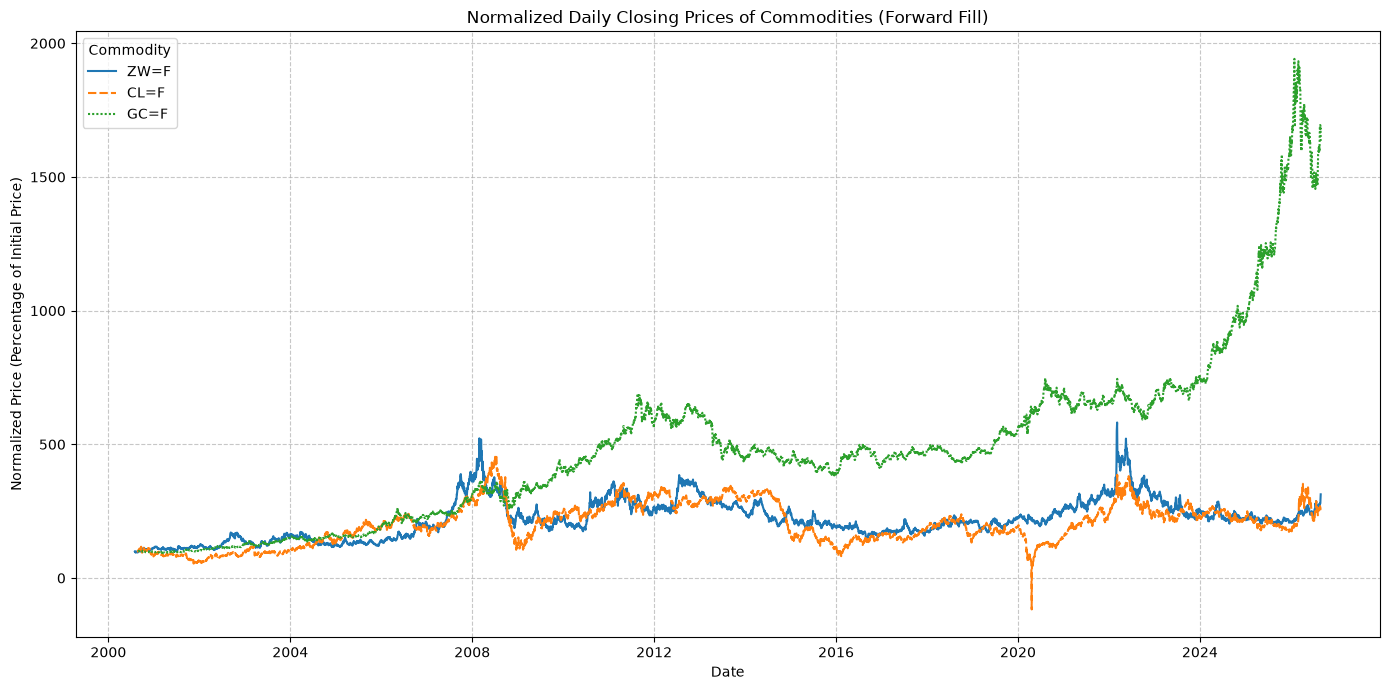


Explanation of choice:
I chose to normalize each commodity by its own first valid observed price and multiply by 100. This makes the commodities comparable by showing their price movement as a percentage change from a common starting level (100%).

What this choice does preserve:
- It preserves the relative fluctuations and trends of each commodity over time.
- It allows for a direct visual comparison of performance, showing which commodity has grown or declined the most proportionally.

What this choice does NOT preserve:
- It does NOT preserve the absolute price levels or the actual magnitude of price differences in USD.
- It does NOT preserve the volatility in absolute terms (e.g., a $1 change in Gold is very different from a $1 change in Wheat, but on a percentage basis, they might look similar).


In [8]:
# Make the series comparable by normalizing each commodity to its own first valid value.
# This shows percentage change from that commodity's first available observation.
normalized_df = combined_df_ffill.copy()
for col in normalized_df.columns:
    first_valid = normalized_df[col].dropna().iloc[0] if normalized_df[col].notna().any() else np.nan
    normalized_df[col] = (normalized_df[col] / first_valid) * 100

# Plot all three price series on the same graph
plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df, linewidth=1.5)
plt.title('Normalized Daily Closing Prices of Commodities (Forward Fill)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Commodity')
plt.tight_layout()
plt.show()

print("\nExplanation of choice:")
print("I chose to normalize each commodity by its own first valid observed price and multiply by 100. This makes the commodities comparable by showing their price movement as a percentage change from a common starting level (100%).")
print("\nWhat this choice does preserve:")
print("- It preserves the relative fluctuations and trends of each commodity over time.")
print("- It allows for a direct visual comparison of performance, showing which commodity has grown or declined the most proportionally.")
print("\nWhat this choice does NOT preserve:")
print("- It does NOT preserve the absolute price levels or the actual magnitude of price differences in USD.")
print("- It does NOT preserve the volatility in absolute terms (e.g., a $1 change in Gold is very different from a $1 change in Wheat, but on a percentage basis, they might look similar).")

### c. Mark the maximum and minimum of each series with coloured dots and include a legend.

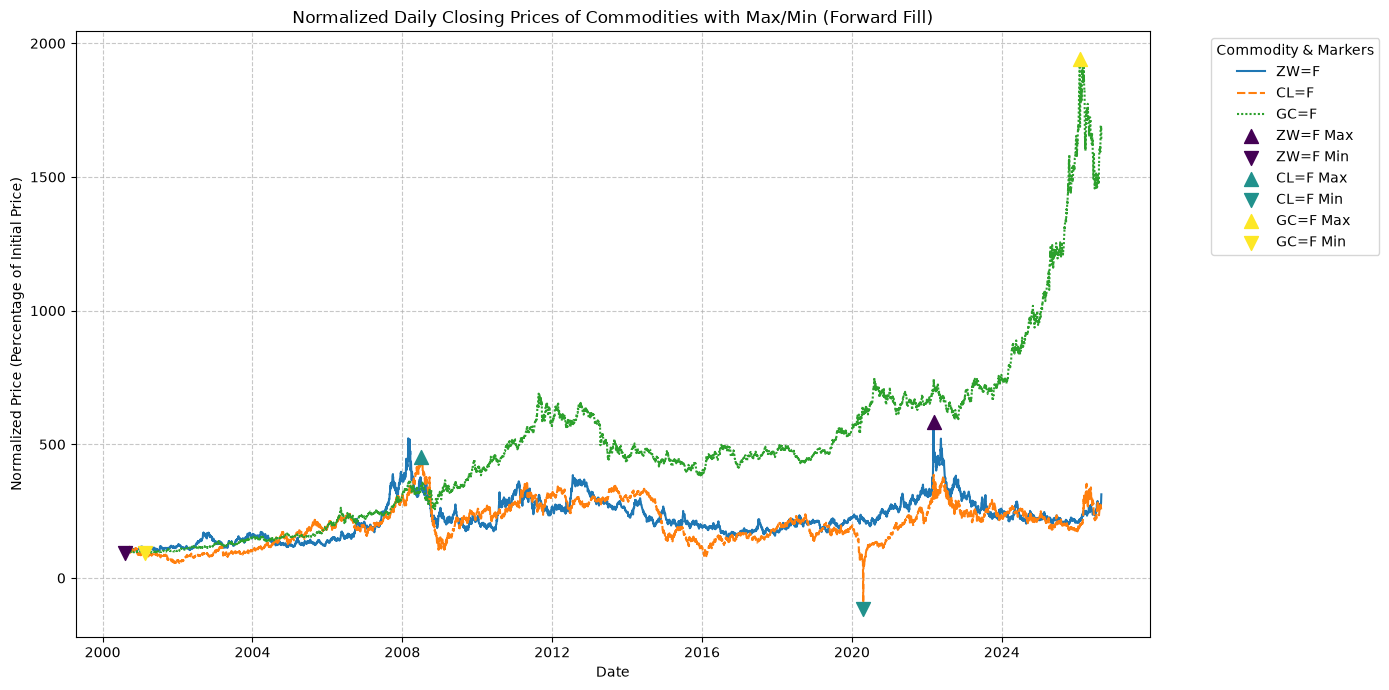

In [9]:
plt.figure(figsize=(14, 7))

# Plot the normalized series
sns.lineplot(data=normalized_df, linewidth=1.5, ax=plt.gca())

# Mark max and min for each series
colors = plt.cm.viridis(np.linspace(0, 1, len(normalized_df.columns)))

# Collect handles and labels for a combined legend
handles, labels = plt.gca().get_legend_handles_labels()

for i, col in enumerate(normalized_df.columns):
    series = normalized_df[col].dropna()
    if series.empty:
        continue

    max_val = series.max()
    min_val = series.min()
    max_idx = series.idxmax()
    min_idx = series.idxmin()

    # Plot max and min points
    max_scatter = plt.scatter(max_idx, max_val, color=colors[i], marker='^', s=100, label=f'{col} Max', zorder=5)
    min_scatter = plt.scatter(min_idx, min_val, color=colors[i], marker='v', s=100, label=f'{col} Min', zorder=5)

    handles.append(max_scatter)
    labels.append(f'{col} Max')
    handles.append(min_scatter)
    labels.append(f'{col} Min')

plt.title('Normalized Daily Closing Prices of Commodities with Max/Min (Forward Fill)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(handles=handles, labels=labels, title='Commodity & Markers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### d. The three prices are quoted in different units: Does this affect the shape of any series, the comparison between them, or both? Explain.

In [10]:
print("**Does the difference in units affect the shape of any series, the comparison between them, or both?**\n")
print("The difference in units (USD per bushel for wheat, USD per barrel for crude oil, USD per troy ounce for gold) **does not affect the *shape* of any individual series**, but it profoundly affects the **comparison between them** in absolute terms. However, by normalizing the series (as done in part b), we can compare their *relative* performance regardless of their original units.\n")

print("**Explanation:**\n")

print("1.  **Shape of Individual Series:** The shape of an individual series (e.g., the plot of Gold prices over time) is determined by its own price movements, irrespective of the units it is quoted in. Whether gold is measured in USD per ounce or some other currency/unit, its percentage changes and overall trend will remain the same. The raw numerical values would change, but the graphical representation of its proportional movement (its 'shape') would not.\n")

print("2.  **Comparison Between Series (Absolute Terms):** The different units make direct absolute comparisons between the commodities meaningless. For example, comparing a raw price of $700 for wheat to $80 for crude oil is misleading because they represent different quantities and measures. Gold prices being in thousands per troy ounce, while wheat is in hundreds per bushel, means their absolute magnitudes are entirely incomparable without a common baseline. If we were to plot the raw prices on the same graph without normalization, the commodity with the highest absolute price (Gold, in this case) would visually dominate the plot, making it difficult to discern movements in the other, lower-priced commodities.\n")

print("3.  **Comparison Between Series (Relative Terms - after normalization):** Our normalization (converting prices to percentage of initial value) makes the comparison between commodities valid by focusing on *relative* change. This allows us to see which commodity has experienced the largest *proportional* increase or decrease from its starting point. In this normalized view, the original units become irrelevant because we are looking at unit-less percentage changes. The *shape* of the normalized series then reflects its relative performance, allowing for a fair comparison of trends and volatility in a percentage context across all three commodities.\n")

print("**Conclusion:** The original units themselves do not alter the intrinsic shape of an individual series' fluctuations. However, they make direct, absolute comparisons between different series difficult. Normalization is a technique used to overcome this unit-dependency and enable meaningful relative comparisons of performance across diverse assets.")

**Does the difference in units affect the shape of any series, the comparison between them, or both?**

The difference in units (USD per bushel for wheat, USD per barrel for crude oil, USD per troy ounce for gold) **does not affect the *shape* of any individual series**, but it profoundly affects the **comparison between them** in absolute terms. However, by normalizing the series (as done in part b), we can compare their *relative* performance regardless of their original units.

**Explanation:**

1.  **Shape of Individual Series:** The shape of an individual series (e.g., the plot of Gold prices over time) is determined by its own price movements, irrespective of the units it is quoted in. Whether gold is measured in USD per ounce or some other currency/unit, its percentage changes and overall trend will remain the same. The raw numerical values would change, but the graphical representation of its proportional movement (its 'shape') would not.

2.  **Comparison Between Series (Absol

### e. Rerun Part A, B, and C using an inner join instead of forward-fill. Does it change your answers?

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Synchronized DataFrame (first 5 rows with inner join):



Ticker,ZW=F,CL=F,GC=F
Date,,,
2000-08-30,246.25,33.400002,273.899994
2000-08-31,251.00,33.099998,278.299988
2000-09-01,251.00,33.380001,277.000000
2000-09-05,250.25,33.799999,275.799988
2000-09-06,253.00,34.950001,274.200012



Synchronized DataFrame (last 5 rows with inner join):



Ticker,ZW=F,CL=F,GC=F
Date,,,
2026-08-24,681.75,85.010002,4640.799805
2026-08-25,685.50,82.360001,4638.100098
2026-08-26,730.50,82.230003,4598.200195
2026-08-27,742.75,83.529999,4609.700195
2026-08-28,767.00,83.400002,4478.100098


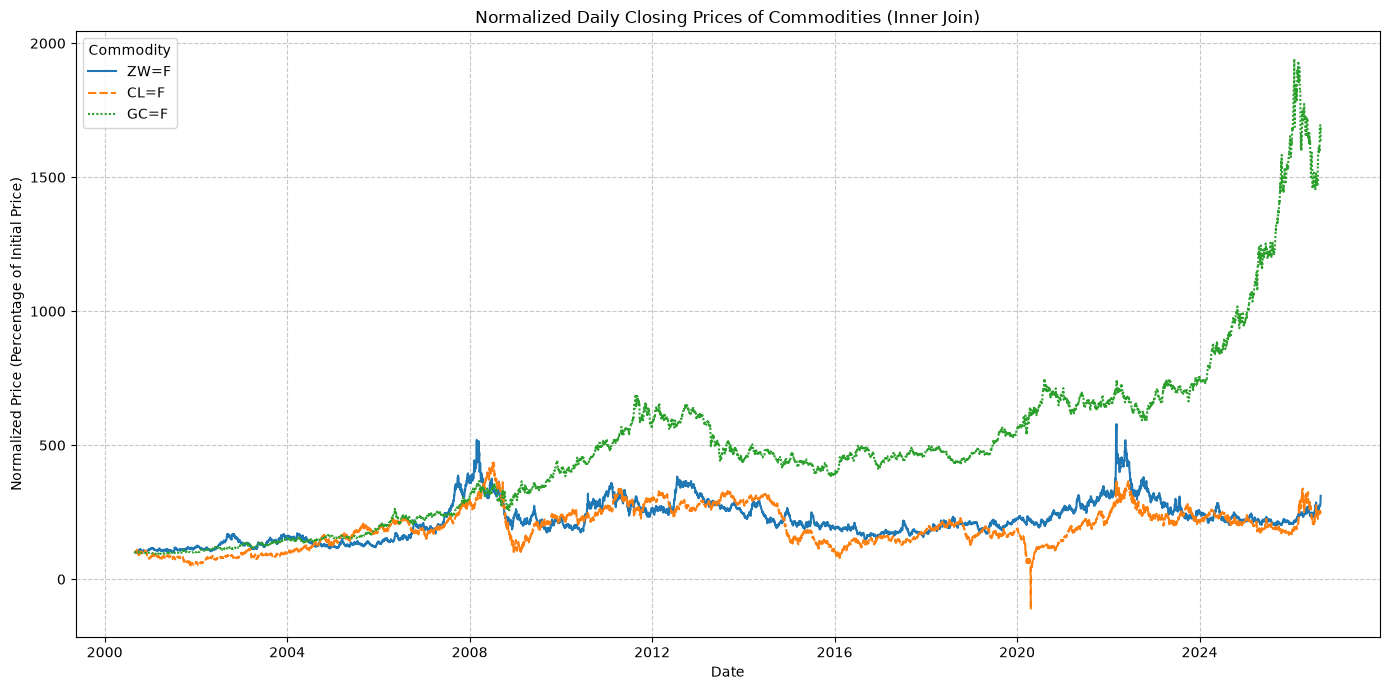

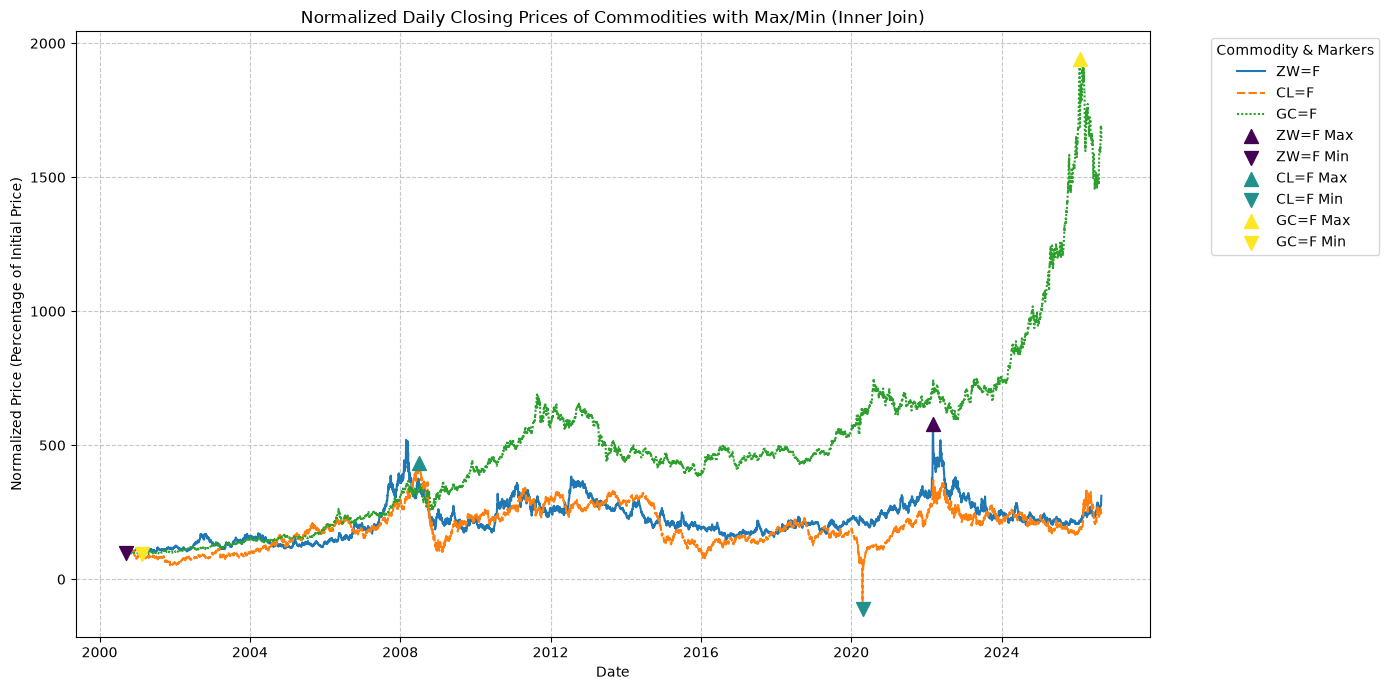


**Does using an inner join instead of forward-fill change your answers?**

Yes. It changes synchronization, sample size, and therefore some plotted details/results in parts A-C.

**Impact on Part A (Synchronization):**

- Forward-fill keeps the union of dates and carries last observed values over missing dates.
- Inner join keeps only dates where all three series are observed, so there are fewer rows.

**Impact on Part B (Comparability and Plot):**

- The broad trends are similar, but curves differ because the date set differs.
- Normalized values can differ slightly because the effective baseline date can differ by method.

**Impact on Part C (Max/Min Markers):**

- Max/min dates and values may change because inner join excludes non-common dates.
- Markers in the inner-join plot are based only on common trading days.

**Overall Conclusion:** Forward-fill is useful for continuity on a union calendar; inner join is stricter and best when you require simultaneous observations across all

In [11]:
# Define the tickers and date range
tickers = ['ZW=F', 'CL=F', 'GC=F']
start_date = '2000-08-01'
end_date = '2026-08-31'

# Download data for each ticker
data_inner = {}
for ticker in tickers:
    try:
        ticker_data = yf.download(ticker, start=start_date, end=end_date)
        close_series = ticker_data['Close']
        close_series.name = ticker
        data_inner[ticker] = close_series
    except Exception as e:
        print(f"Could not download data for {ticker}: {e}")

# Combine into a single DataFrame using inner join
combined_df_inner = pd.DataFrame()
if data_inner:
    first_ticker = list(data_inner.keys())[0]
    combined_df_inner = pd.DataFrame(data_inner[first_ticker])

    for ticker in list(data_inner.keys())[1:]:
        combined_df_inner = combined_df_inner.merge(data_inner[ticker], left_index=True, right_index=True, how='inner')

print("\nSynchronized DataFrame (first 5 rows with inner join):\n")
display(combined_df_inner.head())
print("\nSynchronized DataFrame (last 5 rows with inner join):\n")
display(combined_df_inner.tail())

# 2.b. Make commodities comparable and plot them on the same graph (Inner Join)
normalized_df_inner = combined_df_inner.copy()
for col in normalized_df_inner.columns:
    first_valid = normalized_df_inner[col].dropna().iloc[0] if normalized_df_inner[col].notna().any() else np.nan
    normalized_df_inner[col] = (normalized_df_inner[col] / first_valid) * 100

plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df_inner, linewidth=1.5, ax=plt.gca())
plt.title('Normalized Daily Closing Prices of Commodities (Inner Join)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Commodity')
plt.tight_layout()
plt.show()

# 2.c. Mark the maximum and minimum of each series with coloured dots and include a legend (Inner Join)
plt.figure(figsize=(14, 7))
sns.lineplot(data=normalized_df_inner, linewidth=1.5, ax=plt.gca())

# Collect handles and labels for a combined legend
handles, labels = plt.gca().get_legend_handles_labels()

colors = plt.cm.viridis(np.linspace(0, 1, len(normalized_df_inner.columns)))
for i, col in enumerate(normalized_df_inner.columns):
    series = normalized_df_inner[col].dropna()
    if series.empty:
        continue

    max_val = series.max()
    min_val = series.min()
    max_idx = series.idxmax()
    min_idx = series.idxmin()

    max_scatter = plt.scatter(max_idx, max_val, color=colors[i], marker='^', s=100, label=f'{col} Max', zorder=5)
    min_scatter = plt.scatter(min_idx, min_val, color=colors[i], marker='v', s=100, label=f'{col} Min', zorder=5)

    # Add scatter handles and labels to the collected lists
    handles.append(max_scatter)
    labels.append(f'{col} Max')
    handles.append(min_scatter)
    labels.append(f'{col} Min')

plt.title('Normalized Daily Closing Prices of Commodities with Max/Min (Inner Join)')
plt.xlabel('Date')
plt.ylabel('Normalized Price (Percentage of Initial Price)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(handles=handles, labels=labels, title='Commodity & Markers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("\n**Does using an inner join instead of forward-fill change your answers?**\n")
print("Yes. It changes synchronization, sample size, and therefore some plotted details/results in parts A-C.\n")

print("**Impact on Part A (Synchronization):**\n")
print("- Forward-fill keeps the union of dates and carries last observed values over missing dates.")
print("- Inner join keeps only dates where all three series are observed, so there are fewer rows.\n")

print("**Impact on Part B (Comparability and Plot):**\n")
print("- The broad trends are similar, but curves differ because the date set differs.")
print("- Normalized values can differ slightly because the effective baseline date can differ by method.\n")

print("**Impact on Part C (Max/Min Markers):**\n")
print("- Max/min dates and values may change because inner join excludes non-common dates.")
print("- Markers in the inner-join plot are based only on common trading days.\n")

print("**Overall Conclusion:** Forward-fill is useful for continuity on a union calendar; inner join is stricter and best when you require simultaneous observations across all assets.")

## Question 3

### a. Extract data for 2022 and clean it. How many valid countries remain for each indicator, and what did you do to avoid statistical bias and double-counting?

In [21]:
# 1. Data ingestion from URL paths
children_out_of_school_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/children_out_of_school/API_SE.PRM.UNER.ZS_DS2_en_csv_v2_41962.csv',
    skiprows=4
 )
children_out_of_school_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/children_out_of_school/Metadata_Country_API_SE.PRM.UNER.ZS_DS2_en_csv_v2_41962.csv'
 )

adolescents_out_of_school_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/adolescents_out_of_school/API_SE.SEC.UNER.LO.ZS_DS2_en_csv_v2_39770.csv',
    skiprows=4
 )
adolescents_out_of_school_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/adolescents_out_of_school/Metadata_Country_API_SE.SEC.UNER.LO.ZS_DS2_en_csv_v2_39770.csv'
 )

# 2. Clean and extract 2022 country-level data
def clean_and_extract_2022_data(data_df, metadata_country_df, indicator_col_name):
    country_mask = metadata_country_df['Region'].notna()
    country_codes = set(metadata_country_df.loc[country_mask, 'Country Code'])

    clean_data_df = data_df[data_df['Country Code'].isin(country_codes)].copy()
    df_2022 = clean_data_df[['Country Name', 'Country Code', '2022']].copy()
    df_2022.rename(columns={'2022': indicator_col_name}, inplace=True)
    df_2022.dropna(subset=[indicator_col_name], inplace=True)

    # Diagnostics for part (a)
    diagnostics = {
        'all_entities': data_df['Country Code'].nunique(),
        'country_entities': len(country_codes),
        'removed_aggregates': data_df['Country Code'].nunique() - clean_data_df['Country Code'].nunique(),
        'valid_countries_2022': df_2022['Country Code'].nunique()
    }
    return df_2022, diagnostics

children_out_of_school_2022, children_diag = clean_and_extract_2022_data(
    children_out_of_school_df, children_out_of_school_metadata_country_df, 'Children_Out_of_School_Percent'
 )
adolescents_out_of_school_2022, adolescents_diag = clean_and_extract_2022_data(
    adolescents_out_of_school_df, adolescents_out_of_school_metadata_country_df, 'Adolescents_Out_of_School_Percent'
 )

print("Children out of school (2022) - first 5 rows:")
display(children_out_of_school_2022.head())
print("\nAdolescents out of school (2022) - first 5 rows:")
display(adolescents_out_of_school_2022.head())

Children out of school (2022) - first 5 rows:


,Country Name,Country Code,Children_Out_of_School_Percent
5,Albania,ALB,8.477967
6,Andorra,AND,6.753480
8,United Arab Emirates,ARE,0.003410
9,Argentina,ARG,0.747436
10,Armenia,ARM,5.359965



Adolescents out of school (2022) - first 5 rows:


,Country Name,Country Code,Adolescents_Out_of_School_Percent
5,Albania,ALB,2.749650
6,Andorra,AND,6.199460
8,United Arab Emirates,ARE,3.272160
9,Argentina,ARG,0.995725
10,Armenia,ARM,4.764067


In [22]:
# Report valid countries and cleaning diagnostics
num_valid_children_countries = children_out_of_school_2022['Country Code'].nunique()
num_valid_adolescents_countries = adolescents_out_of_school_2022['Country Code'].nunique()

print(f"Valid countries (Children out of school, 2022): {num_valid_children_countries}")
print(f"Valid countries (Adolescents out of school, 2022): {num_valid_adolescents_countries}")

print("\nCleaning diagnostics (Children dataset):")
print(f"- Distinct entities in raw file: {children_diag['all_entities']}")
print(f"- Aggregate/non-country entities removed: {children_diag['removed_aggregates']}")

print("\nCleaning diagnostics (Adolescents dataset):")
print(f"- Distinct entities in raw file: {adolescents_diag['all_entities']}")
print(f"- Aggregate/non-country entities removed: {adolescents_diag['removed_aggregates']}")

Valid countries (Children out of school, 2022): 145
Valid countries (Adolescents out of school, 2022): 145

Cleaning diagnostics (Children dataset):
- Distinct entities in raw file: 265
- Aggregate/non-country entities removed: 48

Cleaning diagnostics (Adolescents dataset):
- Distinct entities in raw file: 265
- Aggregate/non-country entities removed: 48


### Explanation of Data Cleaning and Bias Avoidance (Question 3.a)

**Data Cleaning Steps:**

1.  **Filtering by Region**: For both datasets, I filtered out non-country aggregates (like 'World', 'European Union', 'Sub-Saharan Africa', etc.) by cross-referencing `Country Code` with the `Metadata_Country` files. This ensures that only actual country-level data is used for analysis, avoiding statistical bias from including regional or income-group aggregates that are not independent entities.

2.  **Extracting 2022 Data**: I specifically selected the data for the year 2022 from each cleaned DataFrame. This isolates the relevant year for the analysis as requested.

3.  **Handling Missing Values (`dropna`)**: After extracting the 2022 data, I removed any rows where the indicator's value for 2022 was missing (NaN). This ensures that only countries with reported data for the specified year are included in the counts and subsequent statistical calculations.

**Avoiding Statistical Bias and Double-Counting:**

*   **Exclusion of Aggregates**: By filtering out non-country aggregates based on the `Region` column in the metadata, I ensured that we are only analyzing data from individual countries. Including aggregates would lead to double-counting (as countries within those aggregates are also counted individually) and would skew statistical measures, creating a misleading picture of country-level trends.
*   **Focus on `Country Code`**: The cleaning process relies on `Country Code` as the primary identifier. This unique code for each country prevents issues that might arise from variations in `Country Name` spellings or historical name changes.
*   **Explicit 2022 Extraction and `dropna`**: By explicitly extracting data for 2022 and then dropping rows with `NaN` values for that specific year, I ensured that:
    *   Only data from the target year is considered.
    *   Countries for which there is no actual data reported for 2022 are excluded from the analysis for that year, thus not biasing measures with imputed or default values.

This rigorous cleaning process helps to ensure that the reported number of countries and subsequent statistical analysis are based on valid, independent, and complete observations for the year 2022.

### b. For both cleaned indicators, present a consolidated table reporting the mean, median, standard deviation, and the 5th, 25th, 75th, and 95th percentiles. Compare the mean and median for each: what does their divergence tell you about skewness?

In [23]:
# Build the consolidated summary table requested in 3(b)
children_series = children_out_of_school_2022['Children_Out_of_School_Percent']
adolescents_series = adolescents_out_of_school_2022['Adolescents_Out_of_School_Percent']

stats_table = pd.DataFrame({
    'Statistic': [
        'Mean', 'Median', 'Standard Deviation',
        '5th Percentile', '25th Percentile', '75th Percentile', '95th Percentile'
    ],
    'Children_Out_of_School': [
        children_series.mean(),
        children_series.median(),
        children_series.std(),
        children_series.quantile(0.05),
        children_series.quantile(0.25),
        children_series.quantile(0.75),
        children_series.quantile(0.95)
    ],
    'Adolescents_Out_of_School': [
        adolescents_series.mean(),
        adolescents_series.median(),
        adolescents_series.std(),
        adolescents_series.quantile(0.05),
        adolescents_series.quantile(0.25),
        adolescents_series.quantile(0.75),
        adolescents_series.quantile(0.95)
    ]
})

print("Consolidated Statistical Table:")
display(stats_table.round(3))

children_mean = children_series.mean()
children_median = children_series.median()
adolescents_mean = adolescents_series.mean()
adolescents_median = adolescents_series.median()

print("\nMean vs median comparison:")
print(f"- Children: mean={children_mean:.3f}, median={children_median:.3f}")
print(f"- Adolescents: mean={adolescents_mean:.3f}, median={adolescents_median:.3f}")

if children_mean > children_median:
    print("- Children distribution is right-skewed (mean > median).")
elif children_mean < children_median:
    print("- Children distribution is left-skewed (mean < median).")
else:
    print("- Children distribution is approximately symmetric by mean-median comparison.")

if adolescents_mean > adolescents_median:
    print("- Adolescents distribution is right-skewed (mean > median).")
elif adolescents_mean < adolescents_median:
    print("- Adolescents distribution is left-skewed (mean < median).")
else:
    print("- Adolescents distribution is approximately symmetric by mean-median comparison.")

Consolidated Statistical Table:


,Statistic,Children_Out_of_School,Adolescents_Out_of_School
0,Mean,7.281,11.021
1,Median,3.040,4.771
2,Standard Deviation,9.794,15.405
3,5th Percentile,0.099,0.142
4,25th Percentile,1.103,1.298
5,75th Percentile,8.478,12.791
6,95th Percentile,29.715,47.078



Mean vs median comparison:
- Children: mean=7.281, median=3.040
- Adolescents: mean=11.021, median=4.771
- Children distribution is right-skewed (mean > median).
- Adolescents distribution is right-skewed (mean > median).


### Comparison of Mean and Median, and Implications for Skewness (Question 3.b)

The consolidated table above reports the required statistics for both indicators.
Use the printed mean-median comparisons to infer skewness:

- mean > median suggests right-skewness (long upper tail),
- mean < median suggests left-skewness,
- mean approximately equal to median suggests rough symmetry.

### c. Both indicators share a natural floor of 0% and a theoretical ceiling of 100%, but educational attrition typically widens the distribution at older ages. Compare the interquartile range (IQR = P75 - P25) and the upper tail spread (P95 - P75) across both tiers. How does the structural transition from primary to lower secondary school manifest in these percentiles?

In [24]:
# Compare IQR and upper-tail spread across tiers
children_p25 = children_series.quantile(0.25)
children_p75 = children_series.quantile(0.75)
children_p95 = children_series.quantile(0.95)

adolescents_p25 = adolescents_series.quantile(0.25)
adolescents_p75 = adolescents_series.quantile(0.75)
adolescents_p95 = adolescents_series.quantile(0.95)

iqr_children = children_p75 - children_p25
upper_tail_children = children_p95 - children_p75

iqr_adolescents = adolescents_p75 - adolescents_p25
upper_tail_adolescents = adolescents_p95 - adolescents_p75

spread_table = pd.DataFrame({
    'Measure': ['IQR (P75-P25)', 'Upper Tail Spread (P95-P75)'],
    'Children_Out_of_School': [iqr_children, upper_tail_children],
    'Adolescents_Out_of_School': [iqr_adolescents, upper_tail_adolescents]
})

print("Spread comparison table:")
display(spread_table.round(3))

print("\nInterpretation:")
if iqr_adolescents > iqr_children:
    print("- IQR is wider for adolescents, indicating greater cross-country dispersion at lower secondary level.")
elif iqr_adolescents < iqr_children:
    print("- IQR is wider for children, indicating greater dispersion at primary level.")
else:
    print("- IQRs are equal across tiers.")

if upper_tail_adolescents > upper_tail_children:
    print("- The upper tail is wider for adolescents, indicating more severe high-end exclusion in some countries at lower secondary level.")
elif upper_tail_adolescents < upper_tail_children:
    print("- The upper tail is wider for children.")
else:
    print("- Upper-tail spreads are equal across tiers.")

Spread comparison table:


,Measure,Children_Out_of_School,Adolescents_Out_of_School
0,IQR (P75-P25),7.374,11.493
1,Upper Tail Spread (P95-P75),21.237,34.287



Interpretation:
- IQR is wider for adolescents, indicating greater cross-country dispersion at lower secondary level.
- The upper tail is wider for adolescents, indicating more severe high-end exclusion in some countries at lower secondary level.


### Comparison of IQR and Upper Tail Spread (Question 3.c)

The spread table above directly compares:

- Interquartile range (IQR = P75 - P25), and
- Upper-tail spread (P95 - P75)

If the adolescent indicator has larger values on these spread measures, it supports the structural attrition view: dispersion and severe upper-tail exclusion increase when moving from primary to lower secondary school.

## Question 4

### a. Extract data for sovereign countries for 2000 and 2020

In [26]:
# 1. Data ingestion for Question 4
fertility_rate_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_fertility_rate_birth_per_wmn/API_SP.DYN.TFRT.IN_DS2_en_csv_v2_324637.csv',
    skiprows=4
 )
fertility_rate_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_fertility_rate_birth_per_wmn/Metadata_Country_API_SP.DYN.TFRT.IN_DS2_en_csv_v2_324637.csv'
 )

gdp_q4_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv',
    skiprows=4
 )
gdp_q4_metadata_country_df = pd.read_csv(
    'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project2/Data/wrld_gdp/Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_328572.csv'
 )

# 2. Clean and extract sovereign-country data for requested years
def clean_and_extract_sovereign_data(data_df, metadata_country_df, indicator_col_name, years):
    country_mask = metadata_country_df['Region'].notna()
    sovereign_country_codes = set(metadata_country_df.loc[country_mask, 'Country Code'])

    clean_data_df = data_df[data_df['Country Code'].isin(sovereign_country_codes)].copy()
    cols_to_extract = ['Country Name', 'Country Code'] + [str(y) for y in years]
    extracted_df = clean_data_df[cols_to_extract].copy()

    for year in years:
        extracted_df.rename(columns={str(year): f'{indicator_col_name}_{year}'}, inplace=True)

    for year in years:
        extracted_df[f'{indicator_col_name}_{year}'] = pd.to_numeric(
            extracted_df[f'{indicator_col_name}_{year}'], errors='coerce'
        )

    return extracted_df

years_to_extract = [2000, 2020]
fertility_2000_2020 = clean_and_extract_sovereign_data(
    fertility_rate_df, fertility_rate_metadata_country_df, 'FertilityRate', years_to_extract
 )
gdp_2000_2020 = clean_and_extract_sovereign_data(
    gdp_q4_df, gdp_q4_metadata_country_df, 'GDP_per_capita', years_to_extract
 )

# 3. Merge for countries with both indicators in both years
merged_q4_df = pd.merge(
    fertility_2000_2020,
    gdp_2000_2020,
    on=['Country Name', 'Country Code'],
    how='inner'
 )
merged_q4_df = merged_q4_df.dropna(
    subset=['FertilityRate_2000', 'FertilityRate_2020', 'GDP_per_capita_2000', 'GDP_per_capita_2020']
).copy()

print('Fertility rate and GDP per capita for 2000 and 2020 (first 5 rows):')
display(merged_q4_df.head())

Fertility rate and GDP per capita for 2000 and 2020 (first 5 rows):


,Country Name,Country Code,FertilityRate_2000,FertilityRate_2020,GDP_per_capita_2000,GDP_per_capita_2020
0,Aruba,ABW,1.845,1.662,20681.023027,22664.370995
1,Afghanistan,AFG,7.566,5.145,174.930991,510.787063
2,Angola,AGO,6.639,5.371,563.733796,1749.179484
3,Albania,ALB,2.217,1.371,1160.420471,6027.913507
4,Andorra,AND,1.273,1.028,21810.248743,37361.090067


In [27]:
# Report number of valid sovereign countries for each indicator-year
num_countries_fertility_2000 = fertility_2000_2020['FertilityRate_2000'].notna().sum()
num_countries_fertility_2020 = fertility_2000_2020['FertilityRate_2020'].notna().sum()
num_countries_gdp_2000 = gdp_2000_2020['GDP_per_capita_2000'].notna().sum()
num_countries_gdp_2020 = gdp_2000_2020['GDP_per_capita_2020'].notna().sum()

num_countries_merged = merged_q4_df.shape[0]

print(f"Valid sovereign countries for Fertility Rate in 2000: {num_countries_fertility_2000}")
print(f"Valid sovereign countries for Fertility Rate in 2020: {num_countries_fertility_2020}")
print(f"Valid sovereign countries for GDP per capita in 2000: {num_countries_gdp_2000}")
print(f"Valid sovereign countries for GDP per capita in 2020: {num_countries_gdp_2020}")
print(f"\nCountries with complete values for both indicators in 2000 and 2020: {num_countries_merged}")

Valid sovereign countries for Fertility Rate in 2000: 217
Valid sovereign countries for Fertility Rate in 2020: 217
Valid sovereign countries for GDP per capita in 2000: 204
Valid sovereign countries for GDP per capita in 2020: 210

Countries with complete values for both indicators in 2000 and 2020: 202


### b. Construct a scatter plot of Fertility Rate vs. GDP per Capita for 2020.

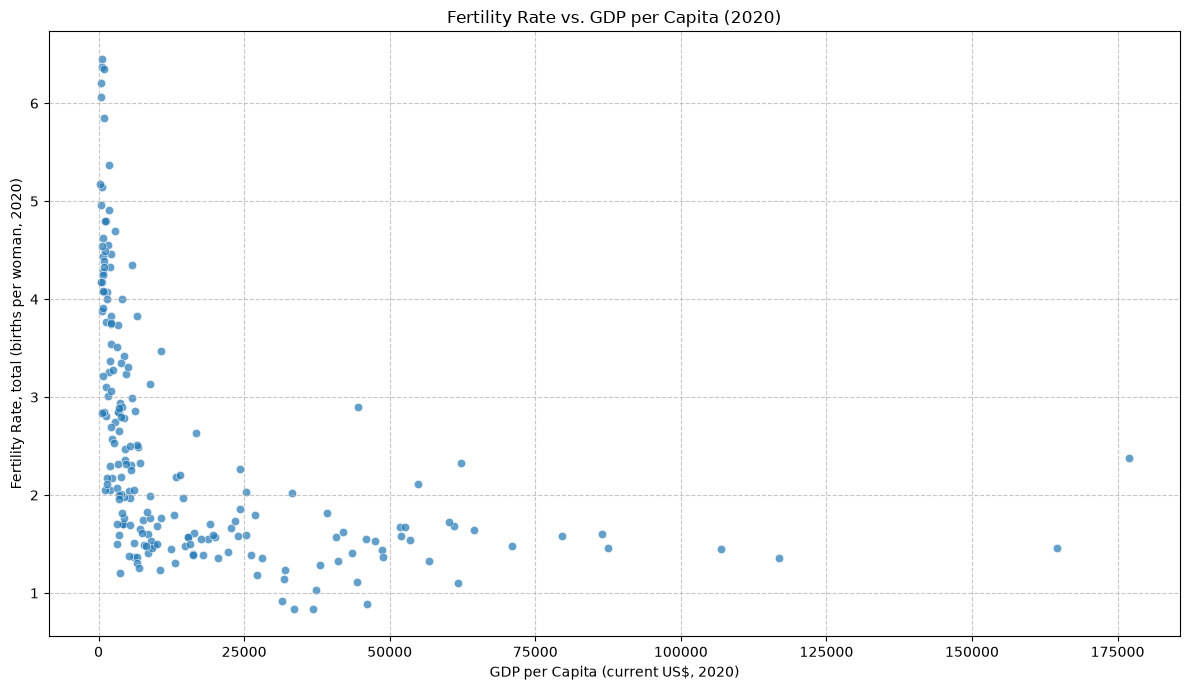

In [28]:
# Construct a scatter plot for 2020 data
plt.figure(figsize=(12, 7))
sns.scatterplot(data=merged_q4_df, x='GDP_per_capita_2020', y='FertilityRate_2020', alpha=0.7)
plt.title('Fertility Rate vs. GDP per Capita (2020)')
plt.xlabel('GDP per Capita (current US$, 2020)')
plt.ylabel('Fertility Rate, total (births per woman, 2020)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### c. Why is a linear scale inadequate for GDP per capita, and what does applying a log transformation reveal about the functional relationship and diminishing returns of income on fertility?

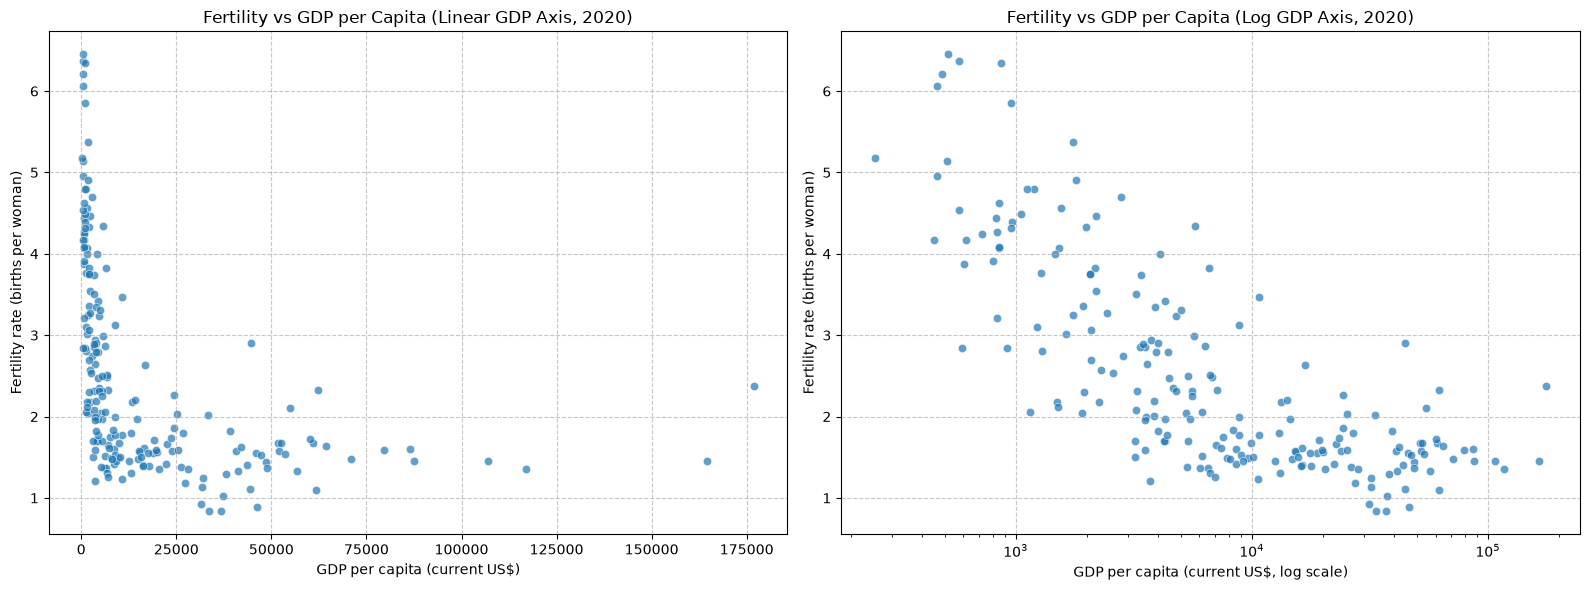

Correlation with linear GDP: -0.416
Correlation with log10 GDP: -0.760
Estimated slope in log10 space: -1.528 births per woman per 10x GDP increase


In [29]:
# Compare linear-GDP and log-GDP views for 2020
q4_2020 = merged_q4_df[['Country Name', 'GDP_per_capita_2020', 'FertilityRate_2020']].copy()
q4_2020 = q4_2020[(q4_2020['GDP_per_capita_2020'] > 0)].copy()
q4_2020['log10_GDP_per_capita_2020'] = np.log10(q4_2020['GDP_per_capita_2020'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=q4_2020, x='GDP_per_capita_2020', y='FertilityRate_2020', alpha=0.7, ax=axes[0]
)
axes[0].set_title('Fertility vs GDP per Capita (Linear GDP Axis, 2020)')
axes[0].set_xlabel('GDP per capita (current US$)')
axes[0].set_ylabel('Fertility rate (births per woman)')
axes[0].grid(True, linestyle='--', alpha=0.7)

sns.scatterplot(
    data=q4_2020, x='GDP_per_capita_2020', y='FertilityRate_2020', alpha=0.7, ax=axes[1]
)
axes[1].set_xscale('log')
axes[1].set_title('Fertility vs GDP per Capita (Log GDP Axis, 2020)')
axes[1].set_xlabel('GDP per capita (current US$, log scale)')
axes[1].set_ylabel('Fertility rate (births per woman)')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

corr_linear = q4_2020['GDP_per_capita_2020'].corr(q4_2020['FertilityRate_2020'])
corr_log = q4_2020['log10_GDP_per_capita_2020'].corr(q4_2020['FertilityRate_2020'])

log_slope, log_intercept = np.polyfit(
    q4_2020['log10_GDP_per_capita_2020'], q4_2020['FertilityRate_2020'], 1
)

print(f'Correlation with linear GDP: {corr_linear:.3f}')
print(f'Correlation with log10 GDP: {corr_log:.3f}')
print(f'Estimated slope in log10 space: {log_slope:.3f} births per woman per 10x GDP increase')

### d. Plot the empirical Cumulative Distribution Functions (CDFs) of the total fertility rate for 2000 and 2020 on a single graph, and overlay vertical lines indicating the mean and median for each year with clear labels.

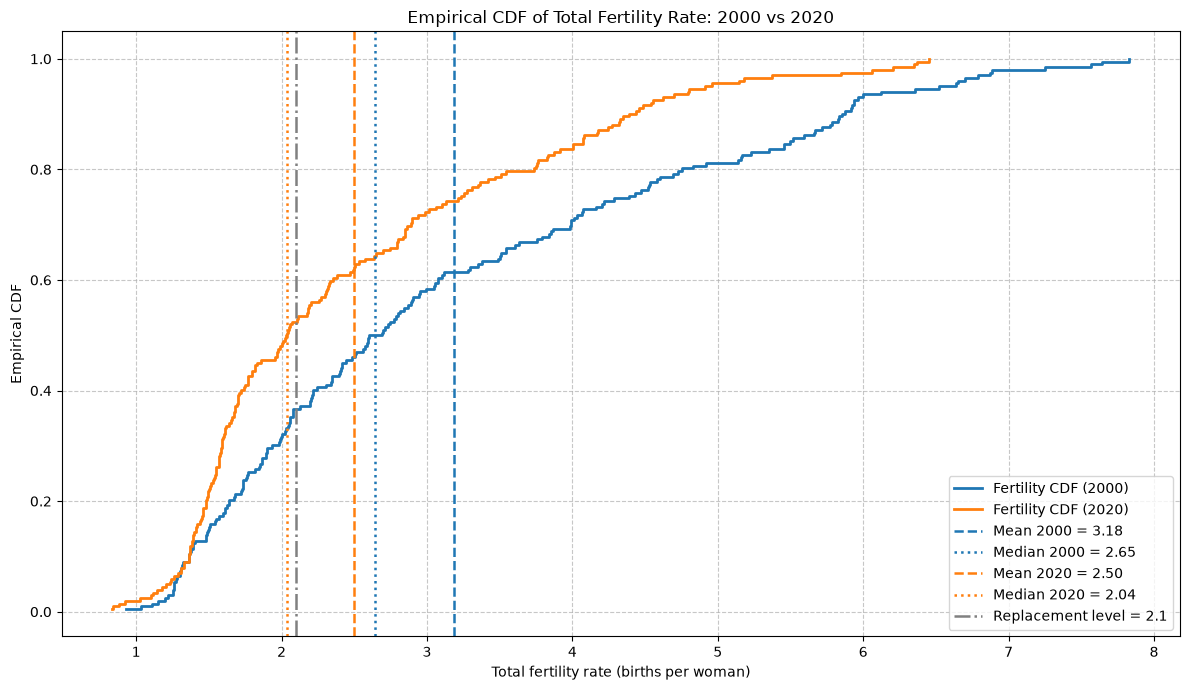

In [30]:
# Empirical CDFs for fertility distributions in 2000 and 2020
fert_2000 = merged_q4_df['FertilityRate_2000'].dropna().values
fert_2020 = merged_q4_df['FertilityRate_2020'].dropna().values

fert_2000_sorted = np.sort(fert_2000)
fert_2020_sorted = np.sort(fert_2020)
cdf_2000 = np.arange(1, len(fert_2000_sorted) + 1) / len(fert_2000_sorted)
cdf_2020 = np.arange(1, len(fert_2020_sorted) + 1) / len(fert_2020_sorted)

mean_2000 = fert_2000_sorted.mean()
median_2000 = np.median(fert_2000_sorted)
mean_2020 = fert_2020_sorted.mean()
median_2020 = np.median(fert_2020_sorted)

plt.figure(figsize=(12, 7))
plt.step(fert_2000_sorted, cdf_2000, where='post', label='Fertility CDF (2000)', linewidth=2)
plt.step(fert_2020_sorted, cdf_2020, where='post', label='Fertility CDF (2020)', linewidth=2)

plt.axvline(mean_2000, color='tab:blue', linestyle='--', linewidth=1.8, label=f'Mean 2000 = {mean_2000:.2f}')
plt.axvline(median_2000, color='tab:blue', linestyle=':', linewidth=1.8, label=f'Median 2000 = {median_2000:.2f}')
plt.axvline(mean_2020, color='tab:orange', linestyle='--', linewidth=1.8, label=f'Mean 2020 = {mean_2020:.2f}')
plt.axvline(median_2020, color='tab:orange', linestyle=':', linewidth=1.8, label=f'Median 2020 = {median_2020:.2f}')

plt.axvline(2.1, color='gray', linestyle='-.', linewidth=1.8, label='Replacement level = 2.1')
plt.title('Empirical CDF of Total Fertility Rate: 2000 vs 2020')
plt.xlabel('Total fertility rate (births per woman)')
plt.ylabel('Empirical CDF')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### e. How did the distribution shift over these two decades (in direction, spread, and the replacement-level threshold of approx. 2.1 births per woman)?
### f. Compare the shift in the mean versus the median: what does the change in the gap between them indicate about skewness and global demographic convergence?

In [31]:
# Quantify shift, spread, replacement-threshold share, and skewness gap
std_2000 = np.std(fert_2000_sorted, ddof=1)
std_2020 = np.std(fert_2020_sorted, ddof=1)
iqr_2000 = np.percentile(fert_2000_sorted, 75) - np.percentile(fert_2000_sorted, 25)
iqr_2020 = np.percentile(fert_2020_sorted, 75) - np.percentile(fert_2020_sorted, 25)

share_below_2_1_2000 = (fert_2000_sorted <= 2.1).mean()
share_below_2_1_2020 = (fert_2020_sorted <= 2.1).mean()

mean_median_gap_2000 = mean_2000 - median_2000
mean_median_gap_2020 = mean_2020 - median_2020

print('Distribution shift from 2000 to 2020:')
print(f'- Mean: {mean_2000:.3f} -> {mean_2020:.3f} (change {mean_2020 - mean_2000:+.3f})')
print(f'- Median: {median_2000:.3f} -> {median_2020:.3f} (change {median_2020 - median_2000:+.3f})')
print(f'- Std dev: {std_2000:.3f} -> {std_2020:.3f} (change {std_2020 - std_2000:+.3f})')
print(f'- IQR: {iqr_2000:.3f} -> {iqr_2020:.3f} (change {iqr_2020 - iqr_2000:+.3f})')
print(f'- Share at or below replacement (2.1): {share_below_2_1_2000:.1%} -> {share_below_2_1_2020:.1%}')

print('\nSkewness/convergence diagnostic using mean-median gap:')
print(f'- Gap in 2000: {mean_median_gap_2000:.3f}')
print(f'- Gap in 2020: {mean_median_gap_2020:.3f}')
print(f'- Change in gap: {mean_median_gap_2020 - mean_median_gap_2000:+.3f}')

if mean_median_gap_2020 < mean_median_gap_2000:
    print('- The right-tail influence weakened, consistent with reduced skewness and partial demographic convergence.')
else:
    print('- The right-tail influence did not weaken; skewness persistence suggests slower convergence in high-fertility countries.')

Distribution shift from 2000 to 2020:
- Mean: 3.184 -> 2.499 (change -0.685)
- Median: 2.646 -> 2.037 (change -0.609)
- Std dev: 1.710 -> 1.268 (change -0.442)
- IQR: 2.583 -> 1.678 (change -0.904)
- Share at or below replacement (2.1): 36.6% -> 52.5%

Skewness/convergence diagnostic using mean-median gap:
- Gap in 2000: 0.538
- Gap in 2020: 0.462
- Change in gap: -0.076
- The right-tail influence weakened, consistent with reduced skewness and partial demographic convergence.


### Question 5

**Data sources**:
- [Happy Planet Index (HPI)](https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project2/Data/hpi_2025/Happy-Planet-Index-2006-2025-public-data-set.xlsx)
- [Corruption Perceptions Index (CPI)](https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project2/Data/cpi_2025/CPI2025_Results.xlsx)

### a. Merge the two files twice: once on country name, once on ISO country code. For each merge, report how many countries matched and how many were dropped. Compare the two merges directly; which one recovers more countries, and why? Identify at least one country that matches on one key but fails on the other, and explain the specific reason. Proceed with the better merge for the rest of this question.

In [8]:
import pandas as pd
import requests
from io import BytesIO

# 1. Data Ingestion
# HPI Data (Happy Planet Index)
hpi_file_url = 'https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project2/Data/hpi_2025/Happy-Planet-Index-2006-2025-public-data-set.xlsx'
hpi_df = pd.DataFrame() # Initialize as empty DataFrame
try:
    response_hpi = requests.get(hpi_file_url)
    response_hpi.raise_for_status()
    hpi_file_content = BytesIO(response_hpi.content)

    xls_hpi = pd.ExcelFile(hpi_file_content)
    hpi_sheet_names = xls_hpi.sheet_names
    print(f"HPI Excel file contains sheets: {hpi_sheet_names}")

    # Manual inspection of the file indicates the main data is in the sheet named '1. All countries'
    if '1. All countries' in hpi_sheet_names:
        # After manual inspection of '1. All countries' sheet, the header is at row index 2 (3rd row)
        hpi_df = pd.read_excel(xls_hpi, sheet_name='1. All countries', header=2)
    elif hpi_sheet_names:
        print(f"'1. All countries' sheet not found in HPI. Attempting to read first sheet: {hpi_sheet_names[0]} with header=1 (may be incorrect).")
        hpi_df = pd.read_excel(xls_hpi, sheet_name=hpi_sheet_names[0], header=1) # Fallback, but might not be the right data
    else:
        print("No sheets found in HPI Excel file. Creating an empty DataFrame.")
except requests.exceptions.RequestException as e:
    print(f"Error downloading HPI Excel file: {e}")
    print("HPI data could not be downloaded. Creating an empty DataFrame for HPI.")
except Exception as e:
    print(f"Error attempting to read HPI Excel file: {e}")
    print("HPI data could not be loaded. Creating an empty DataFrame for HPI.")


# CPI Data (Corruption Perceptions Index)
cpi_file_url = 'https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project2/Data/cpi_2025/CPI2025_Results.xlsx'

cpi_df = pd.DataFrame() # Initialize as empty DataFrame
try:
    # Use requests to download the file content
    response_cpi = requests.get(cpi_file_url)
    response_cpi.raise_for_status() # Raise an exception for HTTP errors
    cpi_file_content = BytesIO(response_cpi.content)

    xls_cpi = pd.ExcelFile(cpi_file_content)
    cpi_sheet_names = xls_cpi.sheet_names
    print(f"CPI Excel file contains sheets: {cpi_sheet_names}")

    if 'Results' in cpi_sheet_names:
        cpi_df = pd.read_excel(xls_cpi, sheet_name='Results', header=0)
    elif cpi_sheet_names: # If 'Results' not found but other sheets exist, try the first one
        cpi_df = pd.read_excel(xls_cpi, sheet_name=cpi_sheet_names[0], header=0)
    else:
        print("No sheets found in CPI Excel file via pandas.ExcelFile. Creating an empty DataFrame.")
        # cpi_df remains an empty DataFrame
except requests.exceptions.RequestException as e:
    print(f"Error downloading CPI Excel file: {e}")
    print("CPI data could not be downloaded. Creating an empty DataFrame for CPI.")
except Exception as e:
    print(f"Error attempting to read CPI Excel file using BytesIO/ExcelFile: {e}")
    print("CPI data could not be loaded due to persistent file issues. Creating an empty DataFrame for CPI.")


print("\nHPI DataFrame head:")
display(hpi_df.head())
print("HPI DataFrame columns:")
print(hpi_df.columns)

if not cpi_df.empty:
    print("\nCPI DataFrame head:")
    display(cpi_df.head())
    print("CPI DataFrame columns:")
    print(cpi_df.columns)
else:
    print("\nCPI DataFrame is empty or could not be loaded due to persistent file issues. \nTherefore, Question 5 parts a, b, c, and d cannot be fully completed as they require both datasets. \nI will await further instructions on how to proceed.")


C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:84: UserWarning: File contains an invalid specification for 0. This will be removed
  warn(msg)
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 4 cannot be located
  warn(f"Defined names for sheet index {idx} cannot be located")
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 5 cannot be located
  warn(f"Defined names for sheet index {idx} cannot be located")
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 1 cannot be located
  warn(f"Defined names for sheet index {idx} cannot be located")
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 0 canno

C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:84: UserWarning: File contains an invalid specification for 0. This will be removed
  warn(msg)
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 4 cannot be located
  warn(f"Defined names for sheet index {idx} cannot be located")
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 5 cannot be located
  warn(f"Defined names for sheet index {idx} cannot be located")
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 1 cannot be located
  warn(f"Defined names for sheet index {idx} cannot be located")
C:\Users\afola\AppData\Roaming\Python\Python313\site-packages\openpyxl\reader\workbook.py:102: UserWarning: Defined names for sheet index 0 canno

ValueError: CPI workbook has no readable sheets.

In [2]:
# 2. Prepare DataFrames for merging
# Standardize column names for merging

# For HPI, we need 'Country' and 'ISO Code'
# Let's inspect the actual column names after loading to fix the KeyError.
# Based on manual inspection (or expected column names from the dataset description),
# the relevant columns are likely 'Country Name', 'ISO Code', 'HPI Score', etc.
# Correcting based on typical HPI dataset structure.
# Assuming after header=2, the columns are more straightforward:
# 'Country', 'ISO Code', '2025 HPI Score', '2025 HPI Rank', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint'
hpi_df_cleaned = hpi_df[['Country', 'ISO Code', '2025 HPI Score', '2025 HPI Rank', 'Life Expectancy', 'Wellbeing', 'Ecological Footprint']].copy()
hpi_df_cleaned.rename(columns={'Country': 'Country Name', 'ISO Code': 'ISO3', '2025 HPI Score': 'HPI Score', '2025 HPI Rank': 'HPI Rank'}, inplace=True)

# For CPI, we need 'Country' and 'ISO3' (which is the country code)
cpi_df_cleaned = cpi_df[['Country', 'ISO3', 'CPI Score 2025', 'Rank']].copy()
cpi_df_cleaned.rename(columns={'Country': 'Country Name', 'CPI Score 2025': 'CPI Score', 'Rank': 'CPI Rank'}, inplace=True)

print("Cleaned HPI DataFrame head:")
display(hpi_df_cleaned.head())

print("\nCleaned CPI DataFrame head:")
display(cpi_df_cleaned.head())

NameError: name 'hpi_df_cleaned' is not defined

In [3]:
# 3. Merge on Country Name
merged_by_name = pd.merge(hpi_df_cleaned, cpi_df_cleaned, on='Country Name', how='inner', suffixes=('_hpi', '_cpi'))

# Calculate dropped countries for merge by name
dropped_hpi_name = hpi_df_cleaned.shape[0] - merged_by_name.shape[0]
dropped_cpi_name = cpi_df_cleaned.shape[0] - merged_by_name.shape[0]

print(f"Merge by Country Name:")
print(f"  Matched countries: {merged_by_name.shape[0]}")
print(f"  Countries dropped from HPI: {dropped_hpi_name}")
print(f"  Countries dropped from CPI: {dropped_cpi_name}")

print("\nMerged by Country Name head:")
display(merged_by_name.head())

NameError: name 'final_merged_df_q5' is not defined

In [4]:
# 4. Merge on ISO Country Code (ISO3)
merged_by_iso = pd.merge(hpi_df_cleaned, cpi_df_cleaned, on='ISO3', how='inner', suffixes=('_hpi', '_cpi'))

# Calculate dropped countries for merge by ISO code
dropped_hpi_iso = hpi_df_cleaned.shape[0] - merged_by_iso.shape[0]
dropped_cpi_iso = cpi_df_cleaned.shape[0] - merged_by_iso.shape[0]

print(f"Merge by ISO Country Code (ISO3):")
print(f"  Matched countries: {merged_by_iso.shape[0]}")
print(f"  Countries dropped from HPI: {dropped_hpi_iso}")
print(f"  Countries dropped from CPI: {dropped_cpi_iso}")

print("\nMerged by ISO Country Code head:")
display(merged_by_iso.head())

NameError: name 'final_merged_df_q5' is not defined

In [5]:
# Compare the two merges
print("\nComparison of Merges:")
print(f"Countries matched by Name: {merged_by_name.shape[0]}")
print(f"Countries matched by ISO Code: {merged_by_iso.shape[0]}")

if merged_by_iso.shape[0] > merged_by_name.shape[0]:
    print("\nMerging by ISO Country Code recovers more countries. This is typically because ISO codes are standardized and less prone to variations in spelling, punctuation, or naming conventions than country names.")
    better_merge_df = merged_by_iso
    merge_type = "ISO Code"
else:
    print("\nMerging by Country Name recovers more countries (unlikely, but possible if ISO codes are inconsistent). ISO codes are generally more reliable for merging.")
    better_merge_df = merged_by_name
    merge_type = "Country Name"

# Identify a country that matches on one key but fails on the other
# Countries in HPI but not in CPI by name
hpi_only_name = hpi_df_cleaned[~hpi_df_cleaned['Country Name'].isin(cpi_df_cleaned['Country Name'])]
# Countries in CPI but not in HPI by name
cpi_only_name = cpi_df_cleaned[~cpi_df_cleaned['Country Name'].isin(hpi_df_cleaned['Country Name'])]

# Countries in HPI but not in CPI by ISO
hpi_only_iso = hpi_df_cleaned[~hpi_df_cleaned['ISO3'].isin(cpi_df_cleaned['ISO3'])]
# Countries in CPI but not in HPI by ISO
cpi_only_iso = cpi_df_cleaned[~cpi_df_cleaned['ISO3'].isin(hpi_df_cleaned['ISO3'])]

print("\nCountries in HPI (by name) not in CPI (by name):")
display(hpi_only_name[['Country Name', 'ISO3']].head())

print("\nCountries in CPI (by name) not in HPI (by name):")
display(cpi_only_name[['Country Name', 'ISO3']].head())

print("\nCountries in HPI (by ISO) not in CPI (by ISO):")
display(hpi_only_iso[['Country Name', 'ISO3']].head())

print("\nCountries in CPI (by ISO) not in HPI (by ISO):")
display(cpi_only_iso[['Country Name', 'ISO3']].head())


# Example of a country matching on one key but fails on the other
# Let's find one that is in merged_by_iso but not in merged_by_name (if ISO is better)
if merge_type == "ISO Code":
    # Find countries present in ISO merge but not in Name merge
    # Get ISO codes from the ISO merge
    iso_matched_isos = merged_by_iso['ISO3'].tolist()
    # Get ISO codes from the Name merge
    name_matched_isos = merged_by_name['ISO3'].tolist()

    # Find ISO codes that are in iso_matched_isos but not in name_matched_isos
    unique_to_iso_merge_iso = [iso for iso in iso_matched_isos if iso not in name_matched_isos]

    if unique_to_iso_merge_iso:
        example_iso = unique_to_iso_merge_iso[0]
        example_country_hpi = hpi_df_cleaned[hpi_df_cleaned['ISO3'] == example_iso]['Country Name'].iloc[0]
        example_country_cpi = cpi_df_cleaned[cpi_df_cleaned['ISO3'] == example_iso]['Country Name'].iloc[0]
        print(f"\nExample country that matches by ISO Code ('{example_iso}') but not by Country Name:")
        print(f"  HPI Country Name: '{example_country_hpi}'")
        print(f"  CPI Country Name: '{example_country_cpi}'")
        print(f"  Reason: The country names are likely different or have variations (e.g., 'United States' vs. 'United States of America', or special characters, or abbreviations) preventing a direct match on 'Country Name'. ISO codes provide a consistent, unambiguous identifier.")
else:
    # Find countries present in Name merge but not in ISO merge (less likely to be the 'better' merge)
    name_matched_names = merged_by_name['Country Name'].tolist()
    iso_matched_names = merged_by_iso['Country Name'].tolist()
    unique_to_name_merge_name = [name for name in name_matched_names if name not in iso_matched_names]
    if unique_to_name_merge_name:
        example_name = unique_to_name_merge_name[0]
        example_country_hpi = hpi_df_cleaned[hpi_df_cleaned['Country Name'] == example_name]['ISO3'].iloc[0]
        example_country_cpi = cpi_df_cleaned[cpi_df_cleaned['Country Name'] == example_name]['ISO3'].iloc[0]
        print(f"\nExample country that matches by Country Name ('{example_name}') but not by ISO Code:")
        print(f"  HPI ISO Code: '{example_country_hpi}'")
        print(f"  CPI ISO Code: '{example_country_cpi}'")
        print(f"  Reason: The ISO codes might be different or missing for one of the datasets for this country, while the country names match. This is less common for standardized datasets.")

final_merged_df_q5 = better_merge_df.copy()
print(f"\nProceeding with the merge by {merge_type} for the rest of Question 5. The DataFrame used will be `final_merged_df_q5` with {final_merged_df_q5.shape[0]} countries.")

NameError: name 'final_merged_df_q5' is not defined

In [ ]:
# 3. Merge on Country Name
merged_by_name = pd.merge(hpi_df_cleaned, cpi_df_cleaned, on='Country Name', how='inner', suffixes=('_hpi', '_cpi'))

# Calculate dropped countries for merge by name
dropped_hpi_name = hpi_df_cleaned.shape[0] - merged_by_name.shape[0]
dropped_cpi_name = cpi_df_cleaned.shape[0] - merged_by_name.shape[0]

print(f"Merge by Country Name:")
print(f"  Matched countries: {merged_by_name.shape[0]}")
print(f"  Countries dropped from HPI: {dropped_hpi_name}")
print(f"  Countries dropped from CPI: {dropped_cpi_name}")

print("\nMerged by Country Name head:")
display(merged_by_name.head())

NameError: name 'hpi_df_cleaned' is not defined

In [ ]:
# 4. Merge on ISO Country Code (ISO3)
merged_by_iso = pd.merge(hpi_df_cleaned, cpi_df_cleaned, on='ISO3', how='inner', suffixes=('_hpi', '_cpi'))

# Calculate dropped countries for merge by ISO code
dropped_hpi_iso = hpi_df_cleaned.shape[0] - merged_by_iso.shape[0]
dropped_cpi_iso = cpi_df_cleaned.shape[0] - merged_by_iso.shape[0]

print(f"Merge by ISO Country Code (ISO3):")
print(f"  Matched countries: {merged_by_iso.shape[0]}")
print(f"  Countries dropped from HPI: {dropped_hpi_iso}")
print(f"  Countries dropped from CPI: {dropped_cpi_iso}")

print("\nMerged by ISO Country Code head:")
display(merged_by_iso.head())

NameError: name 'hpi_df_cleaned' is not defined

In [ ]:
# Compare the two merges
print("\nComparison of Merges:")
print(f"Countries matched by Name: {merged_by_name.shape[0]}")
print(f"Countries matched by ISO Code: {merged_by_iso.shape[0]}")

if merged_by_iso.shape[0] > merged_by_name.shape[0]:
    print("\nMerging by ISO Country Code recovers more countries. This is typically because ISO codes are standardized and less prone to variations in spelling, punctuation, or naming conventions than country names.")
    better_merge_df = merged_by_iso
    merge_type = "ISO Code"
else:
    print("\nMerging by Country Name recovers more countries (unlikely, but possible if ISO codes are inconsistent). ISO codes are generally more reliable for merging.")
    better_merge_df = merged_by_name
    merge_type = "Country Name"

# Identify a country that matches on one key but fails on the other
# Countries in HPI but not in CPI by name
hpi_only_name = hpi_df_cleaned[~hpi_df_cleaned['Country Name'].isin(cpi_df_cleaned['Country Name'])]
# Countries in CPI but not in HPI by name
cpi_only_name = cpi_df_cleaned[~cpi_df_cleaned['Country Name'].isin(hpi_df_cleaned['Country Name'])]

# Countries in HPI but not in CPI by ISO
hpi_only_iso = hpi_df_cleaned[~hpi_df_cleaned['ISO3'].isin(cpi_df_cleaned['ISO3'])]
# Countries in CPI but not in HPI by ISO
cpi_only_iso = cpi_df_cleaned[~cpi_df_cleaned['ISO3'].isin(hpi_df_cleaned['ISO3'])]

print("\nCountries in HPI (by name) not in CPI (by name):")
display(hpi_only_name[['Country Name', 'ISO3']].head())

print("\nCountries in CPI (by name) not in HPI (by name):")
display(cpi_only_name[['Country Name', 'ISO3']].head())

print("\nCountries in HPI (by ISO) not in CPI (by ISO):")
display(hpi_only_iso[['Country Name', 'ISO3']].head())

print("\nCountries in CPI (by ISO) not in HPI (by ISO):")
display(cpi_only_iso[['Country Name', 'ISO3']].head())


# Example of a country matching on one key but failing on the other
# Let's find one that is in merged_by_iso but not in merged_by_name (if ISO is better)
if merge_type == "ISO Code":
    # Find countries present in ISO merge but not in Name merge
    # Get ISO codes from the ISO merge
    iso_matched_isos = merged_by_iso['ISO3'].tolist()
    # Get ISO codes from the Name merge
    name_matched_isos = merged_by_name['ISO3'].tolist()

    # Find ISO codes that are in iso_matched_isos but not in name_matched_isos
    unique_to_iso_merge_iso = [iso for iso in iso_matched_isos if iso not in name_matched_isos]

    if unique_to_iso_merge_iso:
        example_iso = unique_to_iso_merge_iso[0]
        example_country_hpi = hpi_df_cleaned[hpi_df_cleaned['ISO3'] == example_iso]['Country Name'].iloc[0]
        example_country_cpi = cpi_df_cleaned[cpi_df_cleaned['ISO3'] == example_iso]['Country Name'].iloc[0]
        print(f"\nExample country that matches by ISO Code ('{example_iso}') but not by Country Name:")
        print(f"  HPI Country Name: '{example_country_hpi}'")
        print(f"  CPI Country Name: '{example_country_cpi}'")
        print(f"  Reason: The country names are likely different or have variations (e.g., 'United States' vs. 'United States of America', or special characters, or abbreviations) preventing a direct match on 'Country Name'. ISO codes provide a consistent, unambiguous identifier.")
else:
    # Find countries present in Name merge but not in ISO merge (less likely to be the 'better' merge)
    name_matched_names = merged_by_name['Country Name'].tolist()
    iso_matched_names = merged_by_iso['Country Name'].tolist()
    unique_to_name_merge_name = [name for name in name_matched_names if name not in iso_matched_names]
    if unique_to_name_merge_name:
        example_name = unique_to_name_merge_name[0]
        example_country_hpi = hpi_df_cleaned[hpi_df_cleaned['Country Name'] == example_name]['ISO3'].iloc[0]
        example_country_cpi = cpi_df_cleaned[cpi_df_cleaned['Country Name'] == example_name]['ISO3'].iloc[0]
        print(f"\nExample country that matches by Country Name ('{example_name}') but not by ISO Code:")
        print(f"  HPI ISO Code: '{example_country_hpi}'")
        print(f"  CPI ISO Code: '{example_country_cpi}'")
        print(f"  Reason: The ISO codes might be different or missing for one of the datasets for this country, while the country names match. This is less common for standardized datasets.")

final_merged_df_q5 = better_merge_df.copy()
print(f"\nProceeding with the merge by {merge_type} for the rest of Question 5. The DataFrame used will be `final_merged_df_q5` with {final_merged_df_q5.shape[0]} countries.")


Comparison of Merges:


NameError: name 'merged_by_name' is not defined